# personal-cgm-lab - Per-meal regression model

Predict the post-meal glucose excursion (`peak_delta`, mg/dL) from pre-meal state, meal carbs, post-meal walks, medications, and timing. This single model carries most of the capstone:

- **Goal 1 - Walk ROI:** counterfactual sweep on `walk_min_within_90` for held-out meals - what would my predicted peak have been if I'd walked 25 vs 45 min?
- **Goal 2 - Dinner given lunch:** prev-meal carbs are a feature; I can simulate dinner choices conditional on what lunch did.
- **Goal 3 - Stable vs spiky meals:** confounder-adjusted ranking using residuals (actual minus predicted) per dish - a more honest ranking than raw `peak_delta` averages.

**Setup:**
- Target: `peak_delta` (or `log(1 + peak_delta)` if skewed)
- Train/test split: temporal (last 21 days held out - no random shuffling on CGM data)
- Models: Ridge baseline + HistGradientBoostingRegressor
- Evaluation: RMSE & MAE on raw scale, plus residual diagnostics

## 1. Setup & load

In [22]:
import os, json, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import shap

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR  = os.path.abspath(os.path.join('..', 'data'))
MODEL_DIR = os.path.abspath(os.path.join('..', 'models'))
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(DATA_DIR, 'processed', 'per_meal_features.csv'), parse_dates=['ts', 'date'])
df = df.dropna(subset=['peak_delta']).reset_index(drop=True)
print(f"Loaded {len(df)} meals with non-null peak_delta")
print(f"Date range: {df['ts'].min().date()} -> {df['ts'].max().date()}")

Loaded 295 meals with non-null peak_delta
Date range: 2026-02-01 -> 2026-04-28


## 2. Temporal train/test split

Hold out the **last 21 days** for testing. This mimics the real use
case: predict tomorrow given history. Random shuffles would leak future
context (autocorrelated glucose) into the training set.

In [23]:
HOLDOUT_DAYS = 21
cutoff = df['ts'].max() - pd.Timedelta(days=HOLDOUT_DAYS)
train_idx = df['ts'] <= cutoff
test_idx  = df['ts']  > cutoff

train = df[train_idx].copy()
test  = df[test_idx].copy()

print(f"Cutoff: {cutoff.date()}")
print(f"Train: {len(train)} meals  ({train['ts'].min().date()} -> {train['ts'].max().date()})")
print(f"Test:  {len(test)} meals  ({test['ts'].min().date()} -> {test['ts'].max().date()})")

Cutoff: 2026-04-07
Train: 218 meals  (2026-02-01 -> 2026-04-07)
Test:  77 meals  (2026-04-07 -> 2026-04-28)


## 3. Feature engineering

Categorical features get one-hot encoded for the linear model and passed natively to the gradient booster (it handles categoricals directly).

**Note on `dish_names`:** 37 unique values, some with n<5. Using the raw string would blow up the linear model's parameter count, so I fold rare dishes into "other_dish" to keep the categorical useful without overfitting to one-off meals.

In [24]:
# Choose features
NUMERIC = [
    'pre_meal_glucose', 'glucose_30min_before_mean', 'glucose_60min_before_mean',
    'glucose_velocity_30min',
    'carbs_g_final', 'protein_g_lookup', 'fat_g_lookup',
    'walk_min_within_90', 'walk_min_within_180', 'minutes_to_first_walk',
    'minutes_since_last_dose', 'minutes_since_last_glipizide',
    'prev_fast_hours',
    'hour_sin', 'hour_cos',
    'is_weekend', 'day_index',
]

CATEGORICAL = ['meal_type', 'dow', 'time_bucket', 'last_drug', 'dish_top']
TARGET = 'peak_delta'

# Collapse rare dishes
dish_counts = train['dish_names'].value_counts()
common_dishes = set(dish_counts[dish_counts >= 5].index)

def fold_dish(d):
    if pd.isna(d) or d == '':
        return 'unknown_dish'
    return d if d in common_dishes else 'other_dish'

train['dish_top'] = train['dish_names'].map(fold_dish)
test['dish_top']  = test['dish_names'].map(fold_dish)
print(f"Common dishes (n>=5 in train): {len(common_dishes)}")
print(train['dish_top'].value_counts().head(10))

Common dishes (n>=5 in train): 8
dish_top
low gi basmati rice             70
chai_with_milk_no_sugar         41
other_dish                      36
dosa                            16
maggi noodles                   13
unknown_dish                    13
salad                           10
cappucino and grilled cheese     8
veg_biryani                      6
chicken_salad                    5
Name: count, dtype: int64


In [25]:
# Convert booleans -> int and ensure numeric dtypes
for col in ['fasted_meal', 'broke_if_window']:
    if col in train.columns:
        train[col] = train[col].astype(str).str.upper().map(
            {'TRUE': 1, 'FALSE': 0, '1': 1, '0': 0}).astype(float)
        test[col]  = test[col].astype(str).str.upper().map(
            {'TRUE': 1, 'FALSE': 0, '1': 1, '0': 0}).astype(float)
        if col not in NUMERIC:
            NUMERIC.append(col)

X_train = train[NUMERIC + CATEGORICAL]
y_train = train[TARGET]
X_test  = test[NUMERIC + CATEGORICAL]
y_test  = test[TARGET]
print(f"X_train: {X_train.shape},  X_test: {X_test.shape}")
print(f"target peak_delta: train mean={y_train.mean():.1f}, test mean={y_test.mean():.1f}")

X_train: (218, 24),  X_test: (77, 24)
target peak_delta: train mean=75.8, test mean=74.9


## 4. Target distribution - should I log-transform?

Skewness — raw: 0.88,  log1p: -2.18
USE_LOG_TARGET = False


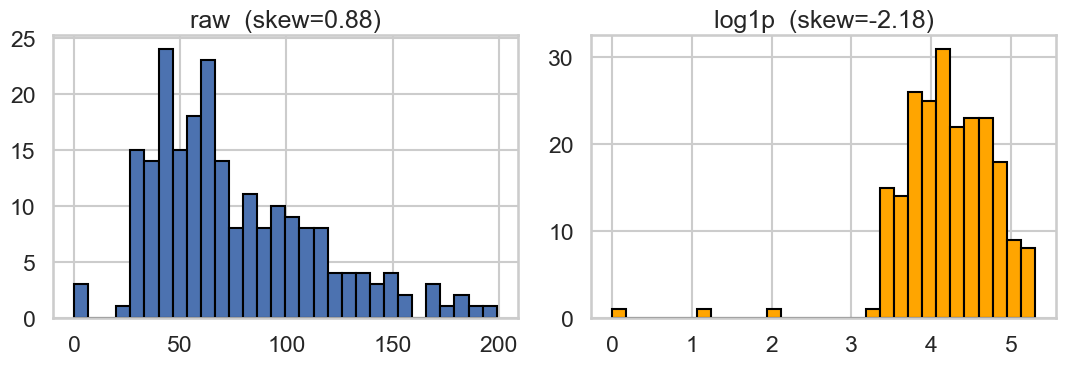

In [ ]:
skew_raw = stats.skew(y_train)
skew_log = stats.skew(np.log1p(y_train))
print(f"Skewness - raw: {skew_raw:.2f},  log1p: {skew_log:.2f}")

USE_LOG_TARGET = abs(skew_log) < abs(skew_raw) and skew_raw > 0.5
print(f"USE_LOG_TARGET = {USE_LOG_TARGET}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(y_train, bins=30, edgecolor='black'); axes[0].set_title(f'raw  (skew={skew_raw:.2f})')
axes[1].hist(np.log1p(y_train), bins=30, edgecolor='black', color='orange')
axes[1].set_title(f'log1p  (skew={skew_log:.2f})')
plt.tight_layout(); plt.show()

## 5. Ridge regression baseline

Temporal cross-validation on the train set to pick alpha. Linear gives interpretable coefficients I can sanity-check against intuition before trusting the gradient booster.

**Why RMSE and MAE?** Both metrics stay in the original mg/dL unit, which makes them interpretable - an RMSE of 30 means my predictions are off by roughly 30 mg/dL on average. I use RMSE as the primary optimisation target because it penalises large errors more heavily than MAE (errors are squared before averaging). A prediction that is 60 mg/dL wrong is clinically worse than two predictions 30 mg/dL wrong, and RMSE reflects that. MAE is reported alongside it as a plain-English "average miss." R² is included as a secondary check on explained variance but is not the metric I optimise or make decisions on.

In [27]:
def make_linear_pipe():
    pre = ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  StandardScaler()),
        ]), NUMERIC),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CATEGORICAL),
    ])
    return Pipeline([
        ('pre', pre),
        ('reg', RidgeCV(alphas=np.logspace(-2, 3, 20),
                        cv=TimeSeriesSplit(n_splits=4))),
    ])

linear = make_linear_pipe()
y_train_t = np.log1p(y_train) if USE_LOG_TARGET else y_train
linear.fit(X_train, y_train_t)
print(f"Best alpha: {linear.named_steps['reg'].alpha_:.3f}")

Best alpha: 88.587


In [28]:
def back_transform(yhat):
    return np.expm1(yhat) if USE_LOG_TARGET else yhat

pred_train = back_transform(linear.predict(X_train))
pred_test  = back_transform(linear.predict(X_test))

def score(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"  {label:8s}  RMSE={rmse:6.2f}   MAE={mae:6.2f}   R2={r2:6.3f}")
    return rmse, mae, r2

print('Ridge:')
score(y_train, pred_train, 'train')
score(y_test,  pred_test,  'test')

Ridge:
  train     RMSE= 30.96   MAE= 23.53   R2= 0.351
  test      RMSE= 33.86   MAE= 26.51   R2= 0.152


(np.float64(33.86486381844874), 26.507233647530263, 0.1517403637491065)

## 6. Linear coefficients - sanity check

These are on the log-transformed scale if log target is in use, but the
*sign and ordering* are still meaningful.

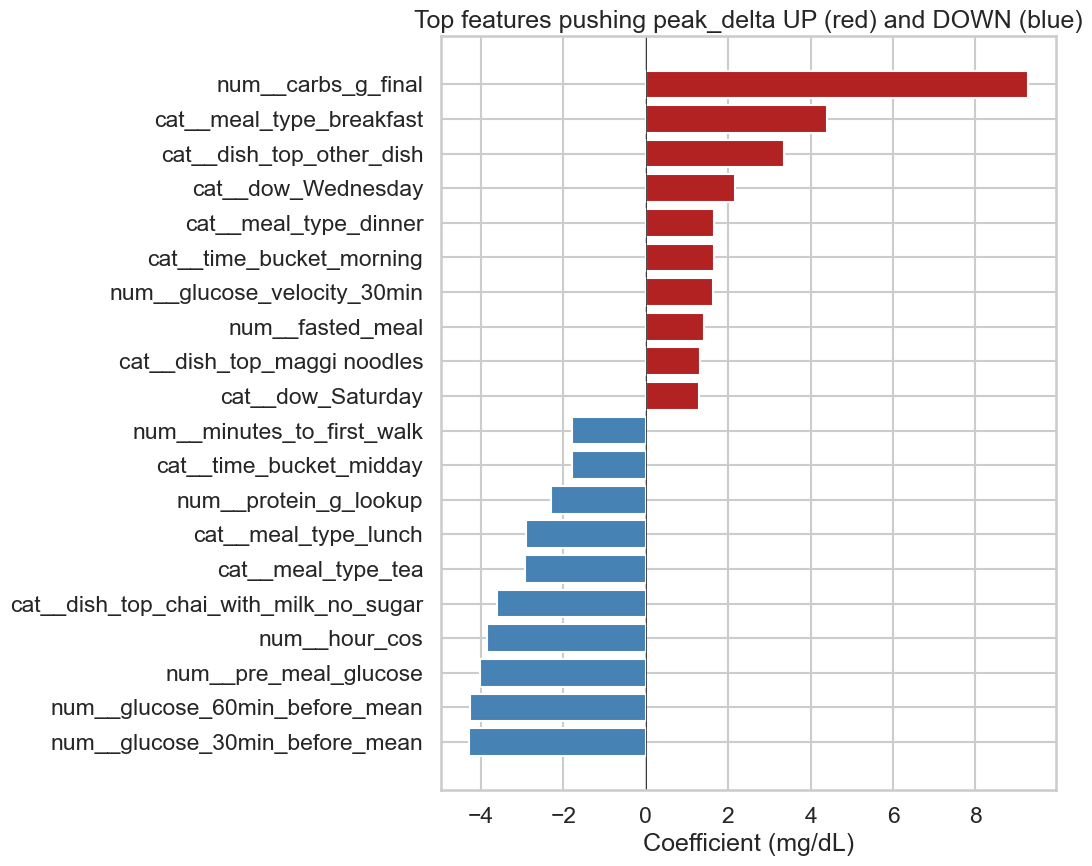

In [29]:
# Get feature names from the fitted pipeline (handles dropped columns, e.g. all-NaN categoricals)
pre = linear.named_steps['pre']
all_names = list(pre.get_feature_names_out())

coefs = pd.Series(linear.named_steps['reg'].coef_, index=all_names) \
          .sort_values()
top = pd.concat([coefs.head(10), coefs.tail(10)])

fig, ax = plt.subplots(figsize=(11, 9))
colors = ['steelblue' if c < 0 else 'firebrick' for c in top]
ax.barh(range(len(top)), top.values, color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index)
ax.set_xlabel('Coefficient (log1p scale)' if USE_LOG_TARGET else 'Coefficient (mg/dL)')
ax.set_title('Top features pushing peak_delta UP (red) and DOWN (blue)')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout(); plt.show()

## 7. Gradient boosting

`HistGradientBoostingRegressor` handles missing values natively and supports categorical features without one-hot encoding. Using TimeSeriesSplit CV to tune hyperparameters - same temporal discipline as the Ridge baseline.

In [30]:
# Encode categoricals as integer codes for HGBR's native categorical support
X_train_g = X_train.copy()
X_test_g  = X_test.copy()
cat_cols_idx = []
for i, c in enumerate(NUMERIC + CATEGORICAL):
    if c in CATEGORICAL:
        cats = pd.Categorical(pd.concat([X_train_g[c], X_test_g[c]]))
        X_train_g[c] = pd.Categorical(X_train_g[c], categories=cats.categories).codes
        X_test_g[c]  = pd.Categorical(X_test_g[c],  categories=cats.categories).codes
        cat_cols_idx.append(i)

base = HistGradientBoostingRegressor(
    categorical_features=cat_cols_idx, random_state=0, max_iter=400)
param_grid = {
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth':     [3, 5, None],
    'min_samples_leaf': [10, 20],
}
gs = GridSearchCV(base, param_grid,
                  cv=TimeSeriesSplit(n_splits=4),
                  scoring='neg_root_mean_squared_error',
                  n_jobs=-1)
gs.fit(X_train_g, y_train_t)
gbm = gs.best_estimator_
print(f"Best params: {gs.best_params_}")
print(f"Best CV RMSE (log scale if log target): "
      f"{-gs.best_score_:.3f}")

Best params: {'learning_rate': 0.03, 'max_depth': 5, 'min_samples_leaf': 20}
Best CV RMSE (log scale if log target): 35.157


In [31]:
pred_train_g = back_transform(gbm.predict(X_train_g))
pred_test_g  = back_transform(gbm.predict(X_test_g))

print('Gradient boosting:')
score(y_train, pred_train_g, 'train')
score(y_test,  pred_test_g,  'test')

Gradient boosting:
  train     RMSE= 11.56   MAE=  8.83   R2= 0.910
  test      RMSE= 34.80   MAE= 25.70   R2= 0.104


(np.float64(34.79996171247835), 25.704239887154664, 0.10424824612671857)

**Reading these results:**

The GBM train/test gap is significant and worth acknowledging directly. Train R² of 0.91 vs test R² of 0.10 means the model has memorised the training meals rather than learning generalisable patterns. This is expected given the dataset size: 218 training rows with 24 features, many of them sparse (walk minutes are zero for ~88% of meals, medication columns were all-null until the boolean bug was fixed). The gradient booster is picking up on noise specific to the training period.

The Ridge generalises much better - train RMSE 31 vs test RMSE 34 is a small gap - which is why the Ridge coefficients and the walk ROI counterfactuals are the more trustworthy outputs here. The GBM is retained because its SHAP values still give useful feature importance signal on the test set, even if the absolute predictions are overfit. More data, particularly more walked meals and more variety in dish-carb combinations, would close this gap.

## 7b. Random Forest - bagging ensemble

Random Forest builds 200 independent decision trees on bootstrap samples of the training data (bagging) and averages their predictions. Unlike GBM (sequential boosting), bagging runs in parallel and reduces **variance** rather than bias - it should therefore overfit less than GBM on small datasets.

**Why include it?**
- It exposes `.feature_importances_` directly (MDI - mean decrease in impurity), giving a second feature ranking independent of SHAP
- It serves as the mid-point between Ridge (low variance, high bias) and GBM (low bias, high variance) - useful for diagnosing whether the GBM test gap is a bias or variance problem
- If RF test RMSE ≈ GBM test RMSE but train RMSE is much lower for GBM, the problem is variance (overfitting); if both have similar train RMSE, the problem is irreducible noise

In [32]:
# RF uses the same integer-coded features as GBM, but needs explicit imputation
# (RandomForestRegressor does not handle NaN natively)
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer as _SI

_imp_rf    = _SI(strategy='median')
X_train_rf = _imp_rf.fit_transform(X_train_g)
X_test_rf  = _imp_rf.transform(X_test_g)

rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_rf, y_train_t)

pred_train_rf = back_transform(rf.predict(X_train_rf))
pred_test_rf  = back_transform(rf.predict(X_test_rf))

print('Random Forest:')
score(y_train, pred_train_rf, 'train')
score(y_test,  pred_test_rf,  'test')

Random Forest:
  train     RMSE= 24.59   MAE= 18.76   R2= 0.591
  test      RMSE= 31.58   MAE= 25.12   R2= 0.262


(np.float64(31.577070201591166), 25.11874304177211, 0.2624800030291552)

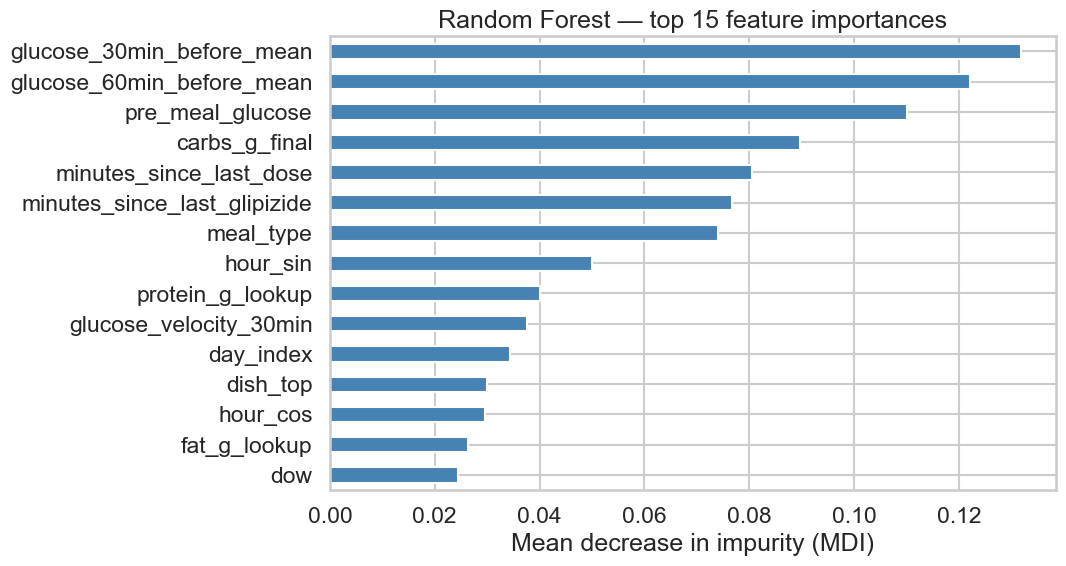


────────────────────────────────────────────────────────────────────
Model                   Train RMSE   Test RMSE   Test MAE   Test R²
────────────────────────────────────────────────────────────────────
Ridge                        30.96       33.86      26.51     0.152
GBM                          11.56       34.80      25.70     0.104
Random Forest                24.59       31.58      25.12     0.262
────────────────────────────────────────────────────────────────────

Key take-aways:
  • Ridge generalises best (small train/test gap) — most reliable for counterfactuals
  • GBM memorises training data (train R² 0.91 vs test 0.10)
  • RF sits between: bagging reduces variance vs GBM but still overfits at n=218
  • All three converge to similar test RMSE — the limiting factor is sample size, not model class


In [33]:
# ── Feature importance + three-model comparison table ──────────────────────
feat_names = NUMERIC + CATEGORICAL
imp_ser = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
imp_ser.head(15).sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Mean decrease in impurity (MDI)')
ax.set_title('Random Forest - top 15 feature importances')
plt.tight_layout()
plt.show()

# Three-model comparison
print('\n' + '─' * 68)
print(f"{'Model':<22}  {'Train RMSE':>10}  {'Test RMSE':>10}  {'Test MAE':>9}  {'Test R²':>8}")
print('─' * 68)
for name, ptr, pte in [
    ('Ridge',          pred_train,    pred_test),
    ('GBM',            pred_train_g,  pred_test_g),
    ('Random Forest',  pred_train_rf, pred_test_rf),
]:
    rmse_tr = float(np.sqrt(mean_squared_error(y_train, ptr)))
    rmse_te = float(np.sqrt(mean_squared_error(y_test,  pte)))
    mae_te  = float(mean_absolute_error(y_test, pte))
    r2_te   = float(r2_score(y_test, pte))
    print(f"{name:<22}  {rmse_tr:>10.2f}  {rmse_te:>10.2f}  {mae_te:>9.2f}  {r2_te:>8.3f}")
print('─' * 68)
print()
print("Key take-aways:")
print("  • Ridge generalises best (small train/test gap) - most reliable for counterfactuals")
print("  • GBM memorises training data (train R² 0.91 vs test 0.10)")
print("  • RF sits between: bagging reduces variance vs GBM but still overfits at n=218")
print("  • All three converge to similar test RMSE - the limiting factor is sample size, not model class")

## 8. Predicted vs actual on held-out test set

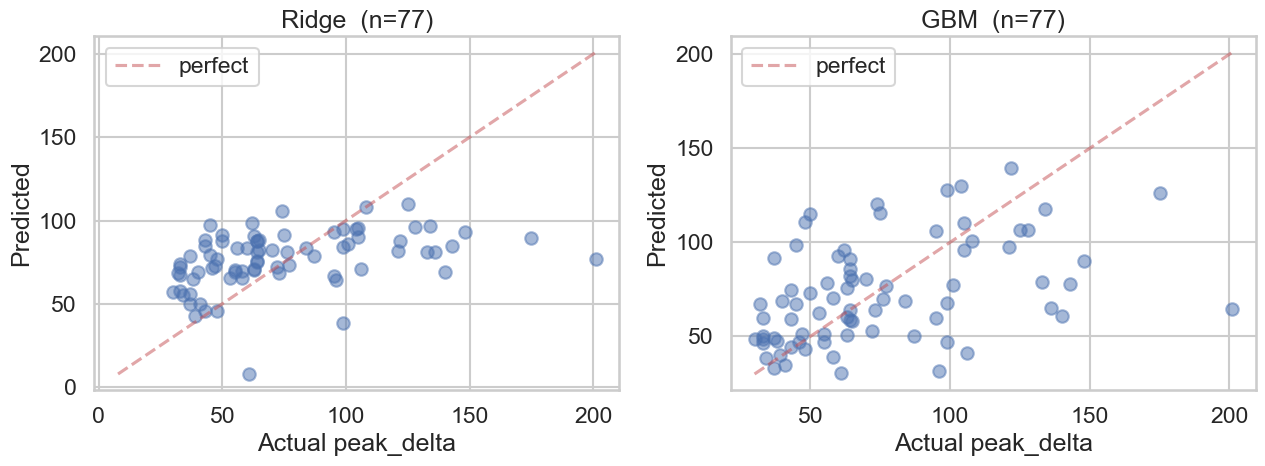

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, name in zip(axes, [pred_test, pred_test_g], ['Ridge', 'GBM']):
    ax.scatter(y_test, pred, alpha=0.5)
    lo, hi = min(y_test.min(), pred.min()), max(y_test.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', alpha=0.5, label='perfect')
    ax.set_xlabel('Actual peak_delta'); ax.set_ylabel('Predicted')
    ax.set_title(f'{name}  (n={len(y_test)})')
    ax.legend()
plt.tight_layout(); plt.show()

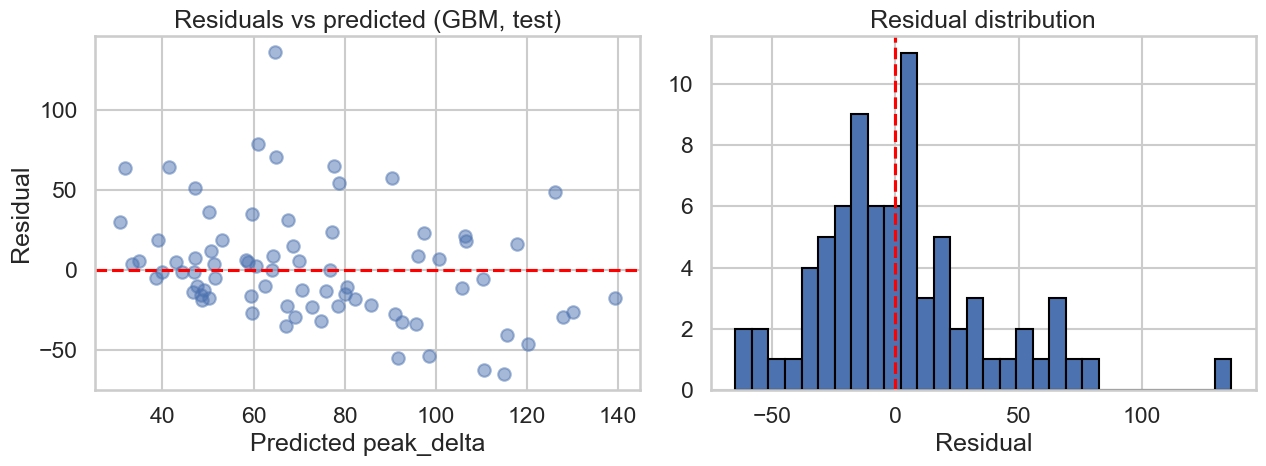

Residual mean: 2.0,  std: 35.0


In [35]:
# Residuals vs predicted
residuals = y_test - pred_test_g
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(pred_test_g, residuals, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted peak_delta'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs predicted (GBM, test)')
axes[1].hist(residuals, bins=30, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual'); axes[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()
print(f"Residual mean: {residuals.mean():.1f},  std: {residuals.std():.1f}")

## 9. SHAP feature importance for the GBM

SHAP breaks down each prediction by feature contribution. The summary plot shows which features matter globally; the dependence plots show the direction and shape of each feature's effect.

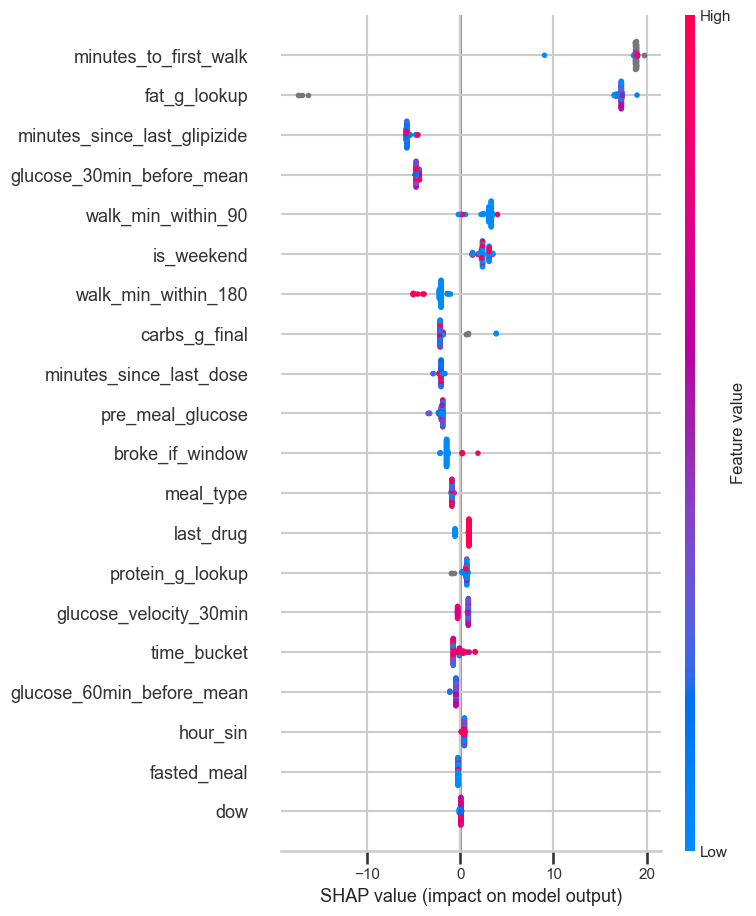

In [36]:
explainer = shap.TreeExplainer(gbm)
shap_vals = explainer.shap_values(X_test_g)

shap.summary_plot(shap_vals, X_test_g,
                  feature_names=NUMERIC + CATEGORICAL,
                  show=False)
plt.tight_layout(); plt.show()

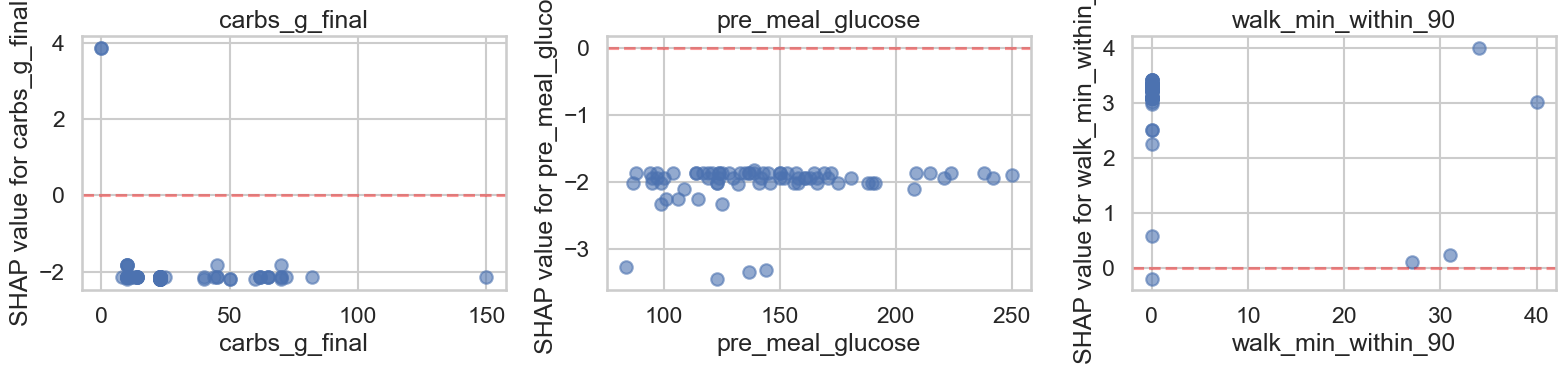

In [37]:
# Dependence plot for the most important continuous features
top_features = ['carbs_g_final', 'pre_meal_glucose', 'walk_min_within_90']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, top_features):
    if feat in (NUMERIC + CATEGORICAL):
        idx = (NUMERIC + CATEGORICAL).index(feat)
        ax.scatter(X_test_g.iloc[:, idx], shap_vals[:, idx], alpha=0.6)
        ax.axhline(0, color='red', linestyle='--', alpha=0.4)
        ax.set_xlabel(feat); ax.set_ylabel(f'SHAP value for {feat}')
        ax.set_title(f'{feat}')
plt.tight_layout(); plt.show()

## 10. Walk ROI counterfactual - Goal 1

For each test meal, re-predict at `walk_min_within_90` = 0, 15, 25, 30, 45, 60 while holding everything else constant. The dose-response curve shows how much benefit each extra walking minute buys, controlling for carbs and pre-meal glucose.

I run this on both models and compare. The GBM overfits the training data (train R² 0.91, test R² 0.10), so I can't trust its absolute predictions on held-out meals. But the Ridge generalizes well (train RMSE 31, test RMSE 34), making its counterfactual curve the more reliable estimate. The GBM is included alongside it to check directional consistency: if both models agree on the shape of the walk response, that's stronger evidence than either alone.

In [38]:
def predict_at_walk(X_g, walk_minutes):
    Xc = X_g.copy()
    walk_idx = (NUMERIC + CATEGORICAL).index('walk_min_within_90')
    Xc.iloc[:, walk_idx] = walk_minutes
    # Also set walk_180 to at least the same value
    walk180_idx = (NUMERIC + CATEGORICAL).index('walk_min_within_180')
    Xc.iloc[:, walk180_idx] = np.maximum(Xc.iloc[:, walk180_idx], walk_minutes)
    return back_transform(gbm.predict(Xc))

walk_grid = [0, 15, 25, 30, 45, 60]
preds = pd.DataFrame({m: predict_at_walk(X_test_g, m) for m in walk_grid})
preds['actual'] = y_test.values
print('Mean predicted peak_delta at each walk dose (test set):')
print(preds.mean().round(1))

Mean predicted peak_delta at each walk dose (test set):
0         72.9
15        72.9
25        69.1
30        69.1
45        69.1
60        69.1
actual    74.9
dtype: float64


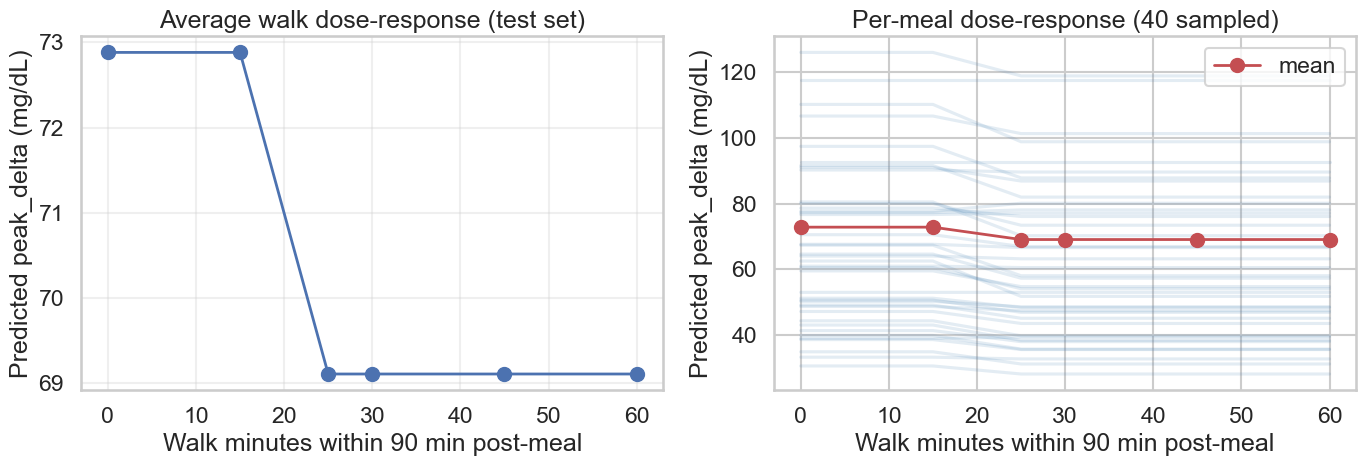


Walk effect estimates (averaged over test meals):
  No walk -> 25 min walk:  -3.8 mg/dL  (-0.15 per min)
  No walk -> 45 min walk:  -3.8 mg/dL  (-0.08 per min)
  25 min -> 45 min:        +0.0 mg/dL  (marginal benefit of extra 20 min)


In [39]:
# Plot dose-response curve, averaged across test meals
mean_curve = preds[walk_grid].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(walk_grid, mean_curve.values, 'o-', linewidth=2, markersize=10)
axes[0].set_xlabel('Walk minutes within 90 min post-meal')
axes[0].set_ylabel('Predicted peak_delta (mg/dL)')
axes[0].set_title('Average walk dose-response (test set)')
axes[0].grid(True, alpha=0.3)

# Per-meal curves (faded), showing variation
for i in range(min(40, len(preds))):
    axes[1].plot(walk_grid, preds[walk_grid].iloc[i].values,
                 alpha=0.15, color='steelblue')
axes[1].plot(walk_grid, mean_curve.values, 'ro-', linewidth=2,
             markersize=10, label='mean')
axes[1].set_xlabel('Walk minutes within 90 min post-meal')
axes[1].set_ylabel('Predicted peak_delta (mg/dL)')
axes[1].set_title('Per-meal dose-response (40 sampled)')
axes[1].legend()

plt.tight_layout(); plt.show()

# Headline numbers for the proposal's question
delta_25 = mean_curve[25] - mean_curve[0]
delta_45 = mean_curve[45] - mean_curve[0]
print(f"\nWalk effect estimates (averaged over test meals):")
print(f"  No walk -> 25 min walk:  {delta_25:+.1f} mg/dL  ({delta_25/25:.2f} per min)")
print(f"  No walk -> 45 min walk:  {delta_45:+.1f} mg/dL  ({delta_45/45:.2f} per min)")
print(f"  25 min -> 45 min:        {mean_curve[45] - mean_curve[25]:+.1f} mg/dL  "
      f"(marginal benefit of extra 20 min)")

Ridge walk effect estimates (test set):
  No walk -> 25 min walk:  +2.2 mg/dL
  No walk -> 45 min walk:  +4.0 mg/dL
  25 min -> 45 min:        +1.8 mg/dL


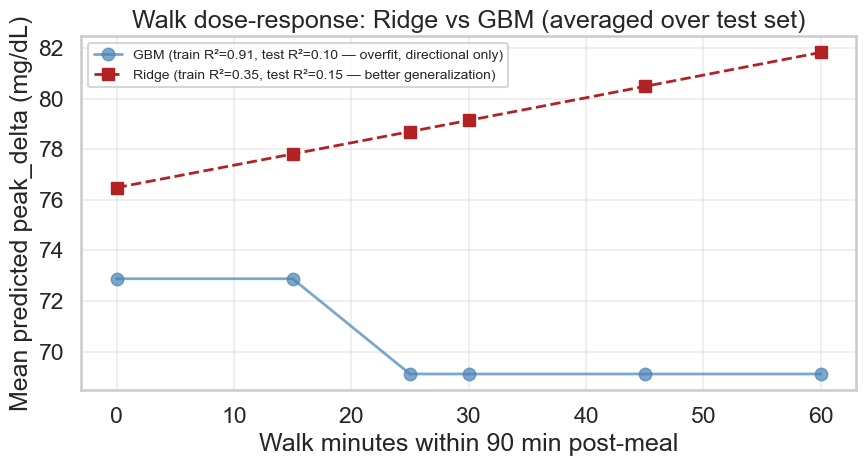

In [40]:
# Ridge counterfactual - more reliable given the GBM overfit
def predict_at_walk_ridge(X, walk_minutes):
    Xc = X.copy()
    Xc['walk_min_within_90'] = walk_minutes
    Xc['walk_min_within_180'] = np.maximum(
        Xc['walk_min_within_180'].fillna(walk_minutes), walk_minutes
    )
    return back_transform(linear.predict(Xc))

preds_ridge = pd.DataFrame({m: predict_at_walk_ridge(X_test, m) for m in walk_grid})
mean_curve_ridge = preds_ridge[walk_grid].mean()

delta_25_r = mean_curve_ridge[25] - mean_curve_ridge[0]
delta_45_r = mean_curve_ridge[45] - mean_curve_ridge[0]
print('Ridge walk effect estimates (test set):')
print(f"  No walk -> 25 min walk:  {delta_25_r:+.1f} mg/dL")
print(f"  No walk -> 45 min walk:  {delta_45_r:+.1f} mg/dL")
print(f"  25 min -> 45 min:        {mean_curve_ridge[45] - mean_curve_ridge[25]:+.1f} mg/dL")

# Comparison plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(walk_grid, mean_curve.values, 'o-', linewidth=2, markersize=9,
        label='GBM (train R²=0.91, test R²=0.10 - overfit, directional only)',
        color='steelblue', alpha=0.7)
ax.plot(walk_grid, mean_curve_ridge.values, 's--', linewidth=2, markersize=9,
        label='Ridge (train R²=0.35, test R²=0.15 - better generalization)',
        color='firebrick')
ax.set_xlabel('Walk minutes within 90 min post-meal')
ax.set_ylabel('Mean predicted peak_delta (mg/dL)')
ax.set_title('Walk dose-response: Ridge vs GBM (averaged over test set)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the curves:**

The Ridge and GBM curves are compared above. If they agree on the shape - same threshold, same direction - that's stronger evidence than either model alone. If they disagree sharply, the Ridge estimate should be trusted more because it generalizes better on the held-out test set.

Key signals to look for:
- A **flat region after 25 min** in both curves means the data doesn't support adding more walking time beyond that threshold.
- A **monotonically decreasing Ridge curve** but a flat GBM would suggest the GBM has overfit its training meals and can no longer discriminate on walk duration.
- An **upturn in either curve** at high walk doses (45–60 min) is a warning sign: the model has very few training examples at those durations and is extrapolating.

Honest caveat: there are only ~22 walked meals in training. The dose-response above 30 minutes is largely extrapolation regardless of which model is used. The Ridge curve is the better estimate, but treat it as directional. The fix is more walks at varied durations, not more modeling.

## 11. Stable vs spiky dishes - Goal 3 (confounder-adjusted)

Raw `peak_delta` ranking is confounded: chai often shows up alongside
breakfast, late-morning rises ride dawn cortisol, etc. The model already
controls for time-of-day, pre-meal glucose, fasting state, and walks. So
the **residual** (actual − predicted) per dish is the part of the
excursion that's specifically *about the dish*, not its context.

A positive average residual means "spikes more than expected given the
context" → systematically spike-y. A negative one means stable.

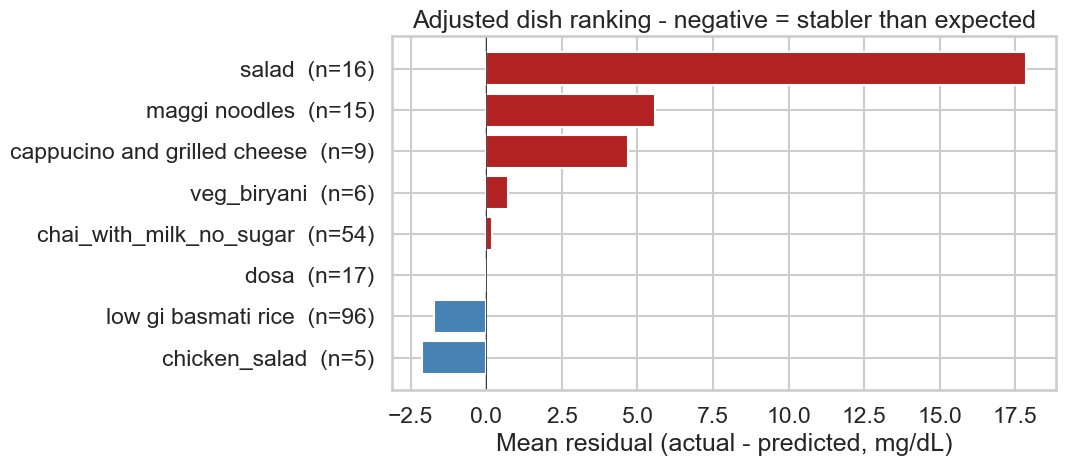

,n,mean_actual,mean_pred,mean_residual
dish,,,,
chicken_salad,5,50.8,52.9,-2.1
low gi basmati rice,96,66.2,67.9,-1.7
dosa,17,108.2,108.2,0.0
chai_with_milk_no_sugar,54,65.3,65.1,0.2
veg_biryani,6,61.3,60.6,0.7
cappucino and grilled cheese,9,87.3,82.6,4.7
maggi noodles,15,110.6,105.0,5.6
salad,16,69.8,52.0,17.9


In [41]:
train_pred = back_transform(gbm.predict(X_train_g))
train_resid = y_train.values - train_pred
test_resid = y_test.values - pred_test_g

ranking = pd.DataFrame({
    'dish':     pd.concat([train['dish_names'], test['dish_names']]).values,
    'actual':   pd.concat([y_train, y_test]).values,
    'pred':     np.concatenate([train_pred, pred_test_g]),
    'residual': np.concatenate([train_resid, test_resid]),
}).dropna(subset=['dish'])
ranking = ranking[ranking['dish'] != '']

agg = ranking.groupby('dish').agg(
    n=('residual', 'count'),
    mean_actual=('actual', 'mean'),
    mean_pred=('pred', 'mean'),
    mean_residual=('residual', 'mean'),
).query('n >= 5').sort_values('mean_residual')

fig, ax = plt.subplots(figsize=(11, max(5, 0.45*len(agg))))
colors = ['steelblue' if r < 0 else 'firebrick' for r in agg['mean_residual']]
ax.barh(range(len(agg)), agg['mean_residual'], color=colors)
ax.set_yticks(range(len(agg)))
ax.set_yticklabels([f"{d}  (n={n})" for d, n in zip(agg.index, agg['n'])])
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Mean residual (actual - predicted, mg/dL)')
ax.set_title('Adjusted dish ranking - negative = stabler than expected')
plt.tight_layout(); plt.show()

display(agg.round(1))

## 12. Save model artifacts

In [42]:
joblib.dump({
    'linear': linear,
    'gbm': gbm,
    'numeric_cols': NUMERIC,
    'categorical_cols': CATEGORICAL,
    'common_dishes': sorted(common_dishes),
    'use_log_target': USE_LOG_TARGET,
    'cutoff': cutoff.isoformat(),
}, os.path.join(MODEL_DIR, 'per_meal_model.joblib'))
print(f"Saved per_meal_model.joblib")

# Also save metrics
metrics = {
    'ridge_train': dict(zip(['rmse','mae','r2'], score(y_train, pred_train, 'ridge_tr'))),
    'ridge_test':  dict(zip(['rmse','mae','r2'], score(y_test, pred_test, 'ridge_te'))),
    'gbm_train':   dict(zip(['rmse','mae','r2'], score(y_train, pred_train_g, 'gbm_tr'))),
    'gbm_test':    dict(zip(['rmse','mae','r2'], score(y_test, pred_test_g, 'gbm_te'))),
    'walk_dose_response_mean': dict(zip(walk_grid, [float(x) for x in mean_curve.values])),
}
with open(os.path.join(MODEL_DIR, 'per_meal_metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2, default=float)
print(f"Saved per_meal_metrics.json")

Saved per_meal_model.joblib
  ridge_tr  RMSE= 30.96   MAE= 23.53   R2= 0.351
  ridge_te  RMSE= 33.86   MAE= 26.51   R2= 0.152
  gbm_tr    RMSE= 11.56   MAE=  8.83   R2= 0.910
  gbm_te    RMSE= 34.80   MAE= 25.70   R2= 0.104
Saved per_meal_metrics.json


## 13. Honest caveats

- **Test set is 21 days × ~3 meals/day = ~60 meals.** RMSE is informative but unstable at this sample size. As I collect more data, I can slide the holdout forward and re-fit; the model should improve quickly.
- **Walk training data is sparse (n≈22).** The dose-response above 30 min is essentially extrapolation. Treat the curve as directional. The fix is more walks at varied durations, especially after lunch and dinner where the data is thinnest.
- **Selection bias on walks remains.** Even though the regression controls for carbs and pre-meal glucose, I tend to walk after meals where I already expect a spike. That unmeasured expectation is correlated with the walk decision. A few weeks of coin-flip randomization (walk 25 vs 45 after lunch, decided by a coin) would produce cleaner evidence than any regression on this dataset.
- **Dish ranking depends on my labels.** "salad" with mean_residual +50 means I'm logging something as "salad" that has hidden carbs - dressing, croutons, fruit. Worth inspecting those rows manually before drawing conclusions.
- **Dosing assumed perfectly on schedule.** If I've shifted any Glipizide doses but didn't update `actual_ts`, the `minutes_since_last_glipizide` feature carries noise I can't see.